<a href="https://colab.research.google.com/github/sandesh-py/DeepLearning_Lab2026/blob/main/CNN_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the Libraries
import Etensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the MNIST Dataset
mnist= tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize Pixel Values to [0,1]
X_train, X_test= X_train/255.0, X_test/255.0
# Reshape the dataset to add channel dimension (needed for CNN)
X_train= X_train.reshape(-1,28,28,1)
X_test= X_test.reshape(-1,28,28,1)

In [ ]:
# Define the CNN Model
model= models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)), # Convolutional Layer
    layers.MaxPooling2D((2,2)), # Pooling Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(), # Flatten for Dense Layers
    layers.Dense(64, activation='relu'), # Fully Connected Layers
    layers.Dense(10, activation='softmax') # Output Layer for 10 classes (digits 0-9)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train the Model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test))
# Evaluate the Model
test_loss, test_acc= model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}" )
# Make Predictions on test image
predictions= model.predict(X_test[:5])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9533 - loss: 0.1487 - val_accuracy: 0.9857 - val_loss: 0.0408
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9895 - val_loss: 0.0344
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9891 - loss: 0.0335 - val_accuracy: 0.9926 - val_loss: 0.0259
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.9909 - val_loss: 0.0314
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9937 - loss: 0.0202 - val_accuracy: 0.9911 - val_loss: 0.0300
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9911 - loss: 0.0300
Test Accuracy: 0.9911
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step


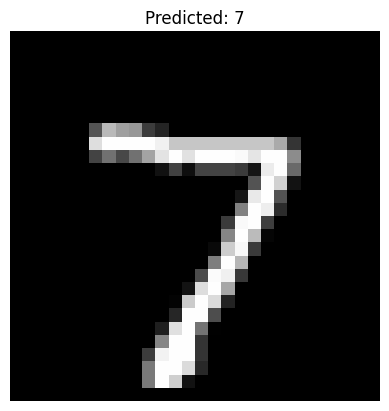

In [ ]:
# Display the first test image with its predicted label
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()